<a href="https://colab.research.google.com/github/yutongzou07/house-price-prediction-ibuyer-analysis/blob/main/Housing_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## Data Loading and Visualize Data

In [ ]:
import pandas as pd  # Importing pandas, which is a library for data manipulation and analysis
# Read the datasets
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [ ]:
import pandas as pd  # Importing pandas, which is a library for data manipulation and analysis
# Read the datasets
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [ ]:
# Display the train dataframe
print(train_df.shape)
print(train_df.columns)

(11581, 17)
Index(['ID', 'NBHD', 'PROP_CLASS', 'LIVING_SQFT', 'FBSMT_SQFT', 'BSMT_AREA',
       'LAND_SQFT', 'GRD_AREA', 'BLDG_AGE', 'RM_AGE', 'BED_RMS', 'FULL_B',
       'HLF_B', 'STORY', 'STYLE_CN', 'UNITS', 'SALE_PRICE'],
      dtype='object')


In [ ]:
# Display the test dataframe
print(test_df.shape)
print(test_df.columns)

(4964, 16)
Index(['ID', 'NBHD', 'PROP_CLASS', 'LIVING_SQFT', 'FBSMT_SQFT', 'BSMT_AREA',
       'LAND_SQFT', 'GRD_AREA', 'BLDG_AGE', 'RM_AGE', 'BED_RMS', 'FULL_B',
       'HLF_B', 'STORY', 'STYLE_CN', 'UNITS'],
      dtype='object')


### Visualization of SALE PRICES


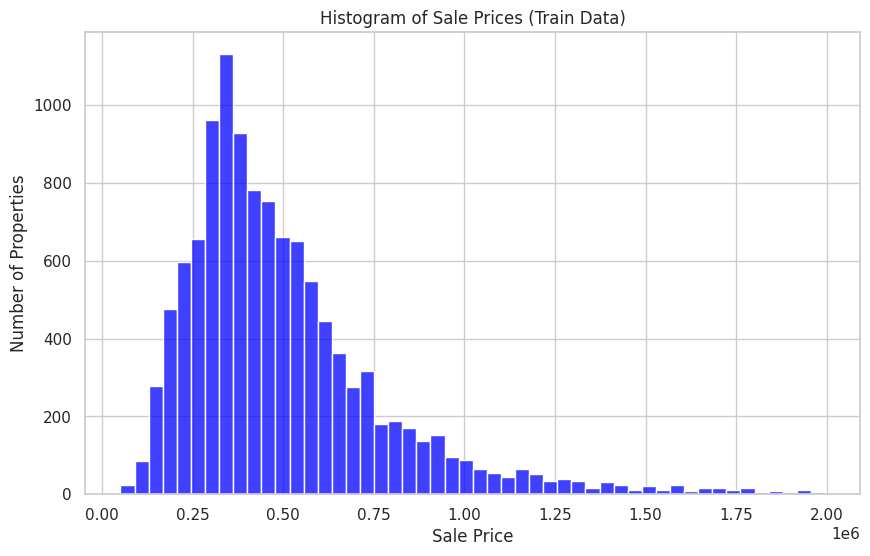

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt  # Importing matplotlib's pyplot, it provides a MATLAB-like interface for making plots and charts

# Set the style
sns.set(style="whitegrid")

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(train_df['SALE_PRICE'], bins=50, color='blue')
plt.title('Histogram of Sale Prices (Train Data)')
plt.xlabel('Sale Price')
plt.ylabel('Number of Properties')
plt.show()

Check the minimum and maximum sale_price in train data.

In [ ]:
print(train_df['SALE_PRICE'].min())
print(train_df['SALE_PRICE'].max())
print(train_df['SALE_PRICE'].median())

51000
1995000
431000.0


### Visualization of Correlation



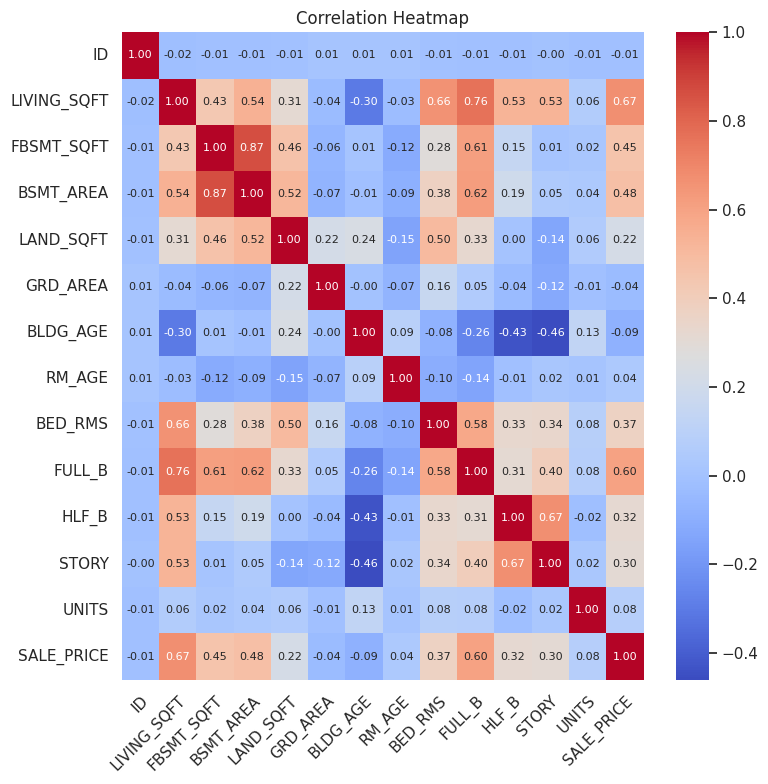

<Figure size 640x480 with 0 Axes>

In [ ]:
# Compute the correlation matrix:
correlation_matrix = train_df.corr(numeric_only=True)

# 1. Increase the figure size for clarity
plt.figure(figsize=(8, 8))

# 2. Use a heatmap with annotations, a color map, and specific formatting for the annotations
ax = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={'size': 8})

# 3. Rotate the x-axis labels for better visibility
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Rotate the y-axis labels
plt.setp(ax.get_yticklabels(), rotation=0)

# 4. Title and display
plt.title('Correlation Heatmap')
plt.tight_layout()  # This can help if any labels are still being cut off
plt.show()

# 5. Optionally save the figure with high resolution
# plt.savefig("heatmap.png", dpi=300)
plt.savefig("heatmap.png", dpi= 300)
plt.show()


We can see that the Sale_Price has high correlation with Living_SQFT and number of Full Bathrooms.

### Distribution of houses over different NBHD

In [ ]:
# Compute the number of houses per neighborhood
House_by_NBHD = train_df['NBHD'].value_counts()
print(House_by_NBHD )

NBHD
CENTRAL PARK                    1049
GATEWAY / GREEN VALLEY RANCH     937
UNION STATION                    369
HAMPDEN                          346
WINDSOR                          316
                                ... 
VALVERDE                          22
GLOBEVILLE                        20
SUN VALLEY                         8
CORY - MERRILL                     4
AURARIA                            1
Name: count, Length: 75, dtype: int64


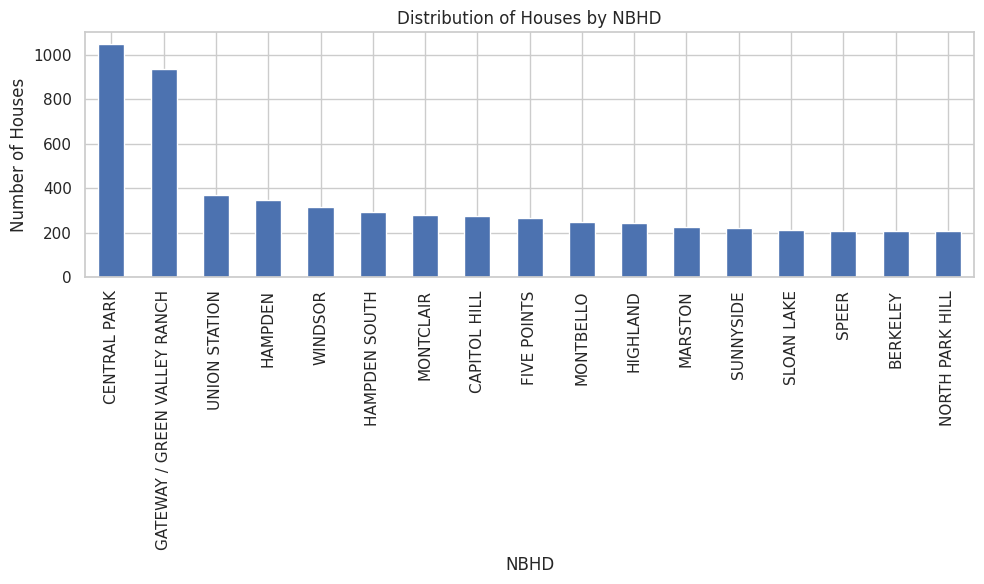

In [ ]:
# Filtering ZIP codes that appear more than once
filtered_House_by_NBHD = House_by_NBHD[House_by_NBHD > 200] #neighborhood where houses are more than 200
filtered_House_by_NBHD.plot(kind='bar', figsize=(10,6))
plt.title('Distribution of Houses by NBHD')
plt.ylabel('Number of Houses')
plt.xlabel('NBHD')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability, if necessary
plt.tight_layout()  # Ensure everything fits without overlapping
plt.show()


---
## Data Preparation



In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4964 entries, 0 to 4963
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           4964 non-null   int64  
 1   NBHD         4964 non-null   object 
 2   PROP_CLASS   4964 non-null   object 
 3   LIVING_SQFT  4964 non-null   int64  
 4   FBSMT_SQFT   4964 non-null   int64  
 5   BSMT_AREA    4964 non-null   int64  
 6   LAND_SQFT    4964 non-null   int64  
 7   GRD_AREA     4964 non-null   int64  
 8   BLDG_AGE     4964 non-null   int64  
 9   RM_AGE       2623 non-null   float64
 10  BED_RMS      4964 non-null   float64
 11  FULL_B       4964 non-null   float64
 12  HLF_B        4964 non-null   int64  
 13  STORY        4964 non-null   float64
 14  STYLE_CN     4964 non-null   object 
 15  UNITS        4964 non-null   float64
dtypes: float64(5), int64(8), object(3)
memory usage: 620.6+ KB


In [ ]:
#mport numpy as np

# Log-transform selected skewed numeric features
#skewed_features = ["LIVING_SQFT", "LAND_SQFT", "GRD_AREA"]
#for feature in skewed_features:
   # train_df[f"LOG_{feature}"] = np.log1p(train_df[feature])
    #test_df[f"LOG_{feature}"] = np.log1p(test_df[feature])

#y = np.log1p(train_df["SALE_PRICE"])
#X = train_df.drop(columns=["SALE_PRICE"])

In [ ]:
# define labels for train data
normalization_factor=100000
train_labels = train_df['SALE_PRICE']/normalization_factor
train_df.drop('SALE_PRICE', axis=1, inplace=True) # drop the sale_prices in features.

In [ ]:
train_ID=train_df['ID']
test_ID=test_df['ID']
train_df.drop('ID', axis=1, inplace=True)
test_df.drop('ID', axis=1, inplace=True)

In [ ]:
# Then we combine the feature vectors in the train data and test data
features=pd.concat(objs=[train_df,test_df],axis=0)

In [ ]:
features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16545 entries, 0 to 4963
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   NBHD         16545 non-null  object 
 1   PROP_CLASS   16545 non-null  object 
 2   LIVING_SQFT  16545 non-null  int64  
 3   FBSMT_SQFT   16545 non-null  int64  
 4   BSMT_AREA    16545 non-null  int64  
 5   LAND_SQFT    16545 non-null  int64  
 6   GRD_AREA     16545 non-null  int64  
 7   BLDG_AGE     16545 non-null  int64  
 8   RM_AGE       8705 non-null   float64
 9   BED_RMS      16545 non-null  float64
 10  FULL_B       16545 non-null  float64
 11  HLF_B        16545 non-null  int64  
 12  STORY        16545 non-null  float64
 13  STYLE_CN     16545 non-null  object 
 14  UNITS        16545 non-null  float64
dtypes: float64(5), int64(7), object(3)
memory usage: 2.0+ MB


In [ ]:
numeric_features = features.dtypes[features.dtypes != 'object'].index
non_numeric_features = features.dtypes[features.dtypes == 'object'].index
numeric_features, non_numeric_features

(Index(['LIVING_SQFT', 'FBSMT_SQFT', 'BSMT_AREA', 'LAND_SQFT', 'GRD_AREA',
        'BLDG_AGE', 'RM_AGE', 'BED_RMS', 'FULL_B', 'HLF_B', 'STORY', 'UNITS'],
       dtype='object'),
 Index(['NBHD', 'PROP_CLASS', 'STYLE_CN'], dtype='object'))

In [ ]:
# If you want to drop the non-numeric features, you just set drop_non_numeric_features= True.
drop_non_numeric_features= False

if drop_non_numeric_features:
    features= features.drop(non_numeric_features, axis=1)
else:
    # One-hot encode categorical features
    features = pd.get_dummies(features, columns=non_numeric_features, dummy_na=True)

# Check for non-numeric columns
non_numeric_cols = features.select_dtypes(include=['object']).columns
if not non_numeric_cols.empty:
    raise ValueError(f"DataFrame contains non-numeric columns: {non_numeric_cols.tolist()}")

In [ ]:
# Standardize numeric features
from sklearn.preprocessing import StandardScaler

# Apply scaler to the combined features DataFrame
scaler = StandardScaler()
features[numeric_features] = scaler.fit_transform(features[numeric_features])

# The following lines are not needed as standardization is applied to the combined features
# After splitting into train/valid/test
# scaler = StandardScaler()

# Fit ONLY on training data
# train[numeric_features] = scaler.fit_transform(train[numeric_features])

# Transform valid and test using training stats
# valid[numeric_features] = scaler.transform(valid[numeric_features])
# test[numeric_features] = scaler.transform(test[numeric_features])

In [ ]:
# recheck the mean and std after standardization
features[numeric_features].mean(), features[numeric_features].std()

(LIVING_SQFT   -7.236413e-17
 FBSMT_SQFT    -6.441911e-19
 BSMT_AREA      3.403476e-17
 LAND_SQFT      3.065276e-17
 GRD_AREA      -1.138071e-17
 BLDG_AGE       2.872018e-18
 RM_AGE         2.795645e-17
 BED_RMS        2.069464e-16
 FULL_B         2.202060e-16
 HLF_B         -2.329824e-17
 STORY         -6.731797e-17
 UNITS          5.607683e-16
 dtype: float64,
 LIVING_SQFT    1.000030
 FBSMT_SQFT     1.000030
 BSMT_AREA      1.000030
 LAND_SQFT      1.000030
 GRD_AREA       1.000030
 BLDG_AGE       1.000030
 RM_AGE         1.000057
 BED_RMS        1.000030
 FULL_B         1.000030
 HLF_B          1.000030
 STORY          1.000030
 UNITS          1.000030
 dtype: float64)

In [ ]:
# After the feature standardization, we can impute the missing values with zeros.
features[numeric_features] = features[numeric_features].fillna(0)

Double check features after data processing.

In [ ]:
features.info()
print(features.columns)

<class 'pandas.core.frame.DataFrame'>
Index: 16545 entries, 0 to 4963
Columns: 105 entries, LIVING_SQFT to STYLE_CN_nan
dtypes: bool(93), float64(12)
memory usage: 3.1 MB
Index(['LIVING_SQFT', 'FBSMT_SQFT', 'BSMT_AREA', 'LAND_SQFT', 'GRD_AREA',
       'BLDG_AGE', 'RM_AGE', 'BED_RMS', 'FULL_B', 'HLF_B',
       ...
       'STYLE_CN_3 STORY', 'STYLE_CN_BI-LEVEL', 'STYLE_CN_CONVERSION',
       'STYLE_CN_END UNIT', 'STYLE_CN_MIDDLE UNIT', 'STYLE_CN_RANCH',
       'STYLE_CN_SPLIT LEVEL', 'STYLE_CN_TRI-LEVEL', 'STYLE_CN_TRI-LEVEL W/B',
       'STYLE_CN_nan'],
      dtype='object', length=105)


In [ ]:
# check whether there is any missing entry
# This drops any column that has 100% missing values

features = features.dropna(axis=1, how='all')

print(features.isnull().sum())

LIVING_SQFT               0
FBSMT_SQFT                0
BSMT_AREA                 0
LAND_SQFT                 0
GRD_AREA                  0
                         ..
STYLE_CN_RANCH            0
STYLE_CN_SPLIT LEVEL      0
STYLE_CN_TRI-LEVEL        0
STYLE_CN_TRI-LEVEL W/B    0
STYLE_CN_nan              0
Length: 105, dtype: int64


In [ ]:
# we extract out the train and test features
train_features = features.iloc[:len(train_labels)]
test_features = features.iloc[len(train_labels):]
train_features.shape, test_features.shape

((11581, 105), (4964, 105))

In [ ]:
import torch
import numpy as np

# Convert training features and labels to PyTorch tensors
train_features = torch.tensor(train_features.values.astype(np.float32), dtype=torch.float32)
test_features = torch.tensor(test_features.values.astype(np.float32), dtype=torch.float32)
train_labels = torch.tensor(train_labels.values.reshape(-1, 1).astype(np.float32), dtype=torch.float32)

In [ ]:
train_labels

tensor([[ 2.8500],
        [12.3000],
        [ 4.2000],
        ...,
        [ 6.0200],
        [ 3.8370],
        [ 5.5000]])

In [ ]:
train_labels.shape

torch.Size([11581, 1])

---
## Training and Validation



In [ ]:
# filling in the missing code to split train data into train and validation
from sklearn.model_selection import train_test_split  # Importing train_test_split function from sklearn for splitting data into training set and validation set
# Splitting the training data: 20% is validation data
train_features, valid_features, train_labels, valid_labels = train_test_split(
    train_features, train_labels, test_size=0.2, random_state=42
)


In [ ]:
print(train_features.shape)
print(valid_features.shape)

torch.Size([9264, 105])
torch.Size([2317, 105])


---
## DataLoaders and Batching



In [ ]:
from torch.utils.data import TensorDataset, DataLoader
train_data = TensorDataset(train_features, train_labels)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
# create dataloader for validation data
valid_data = TensorDataset(valid_features, valid_labels)
valid_loader = DataLoader(valid_data, batch_size = 128, shuffle = True)

In [ ]:
test_data = TensorDataset(test_features)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

sanity check

In [ ]:
# obtain one batch of training data
dataiter = iter(train_loader)
features, labels = next(dataiter)

print('Sample input size: ', features.size()) # batch_size, seq_length
print('Sample input: \n', features)
print()
print('Sample label size: ', labels.size()) # batch_size
print('Sample label: \n', labels)

Sample input size:  torch.Size([128, 105])
Sample input: 
 tensor([[-0.9145, -0.6921, -0.8232,  ...,  1.0000,  0.0000,  0.0000],
        [ 0.0949, -0.6921,  0.1182,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0036, -0.6921,  0.3295,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [-1.4529, -0.6921, -0.8232,  ...,  0.0000,  0.0000,  0.0000],
        [ 1.5781,  1.6740,  1.3973,  ...,  0.0000,  0.0000,  0.0000],
        [-0.8779, -0.2619, -0.0155,  ...,  0.0000,  0.0000,  0.0000]])

Sample label size:  torch.Size([128, 1])
Sample label: 
 tensor([[ 3.7500],
        [ 3.0250],
        [ 7.4844],
        [ 3.3580],
        [ 2.5000],
        [10.2500],
        [ 3.4000],
        [10.5733],
        [ 6.0500],
        [ 3.4678],
        [ 2.0533],
        [ 3.2218],
        [ 6.0200],
        [ 3.1910],
        [ 6.7500],
        [ 5.3500],
        [ 4.9990],
        [ 4.5500],
        [ 7.2000],
        [ 3.1500],
        [ 3.0500],
        [ 5.6000],
        [ 4.8000],
        [ 2.

---
## Linear Regression as Benchmark


In [ ]:
# Build a linear regression model network
import torch.nn as nn
lin_net = nn.Linear(train_features.shape[1], 1)

In [ ]:
lin_net

Linear(in_features=105, out_features=1, bias=True)

In [ ]:
features, labels = next(dataiter)
output=lin_net(features)
output.shape,labels.shape

(torch.Size([128, 1]), torch.Size([128, 1]))

---
## Train the model

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
lin_net = lin_net.to(device)

In [ ]:
#Since both the output and the label are real valued, we will use the standard mean-squared loss.
criterion = nn.MSELoss()

In [ ]:
#Write code to train the network and save training and validation error.
import torch.optim as optim
torch.manual_seed(14)
optimizer = optim.SGD(lin_net.parameters(), lr=0.001)
num_epochs = 200

train_MERs, valid_MERs = [], []
def compute_mer(y_true, y_pred, eps=1e-8):
    y_true = y_true * 100000
    y_pred = y_pred * 100000
    rel_error = torch.abs(y_pred - y_true) / torch.clamp(y_true, min=eps)
    return torch.median(rel_error).item()

for epoch in range(num_epochs):
    lin_net.train()
    running_loss = 0.0
    n_obs = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = lin_net(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * features.size(0)
        n_obs += features.size(0)

    train_loss = running_loss / n_obs

    # Validation
    lin_net.eval()
    with torch.no_grad():
        val_loss = 0.0
        n_val = 0
        for features, labels in valid_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = lin_net(features)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * features.size(0)
            n_val += features.size(0)
        val_loss /= n_val

        # Compute MER for full train and valid sets
        train_preds = lin_net(train_features.to(device))
        val_preds = lin_net(valid_features.to(device))
        train_mer = compute_mer(train_labels.to(device), train_preds)
        val_mer = compute_mer(valid_labels.to(device), val_preds)
        train_MERs.append(train_mer)
        valid_MERs.append(val_mer)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train MER: {train_mer:.4f}, Val MER: {val_mer:.4f}")

Epoch [1/200] Train Loss: 25.8234, Val Loss: 20.3343, Train MER: 0.7671, Val MER: 0.7695
Epoch [10/200] Train Loss: 4.4289, Val Loss: 4.4206, Train MER: 0.2300, Val MER: 0.2321
Epoch [20/200] Train Loss: 3.8378, Val Loss: 3.8676, Train MER: 0.2209, Val MER: 0.2198
Epoch [30/200] Train Loss: 3.6286, Val Loss: 3.6693, Train MER: 0.2109, Val MER: 0.2100
Epoch [40/200] Train Loss: 3.4990, Val Loss: 3.5461, Train MER: 0.2041, Val MER: 0.2025
Epoch [50/200] Train Loss: 3.4040, Val Loss: 3.4544, Train MER: 0.1993, Val MER: 0.1974
Epoch [60/200] Train Loss: 3.3273, Val Loss: 3.3795, Train MER: 0.1950, Val MER: 0.1939
Epoch [70/200] Train Loss: 3.2622, Val Loss: 3.3147, Train MER: 0.1906, Val MER: 0.1894
Epoch [80/200] Train Loss: 3.2053, Val Loss: 3.2572, Train MER: 0.1867, Val MER: 0.1859
Epoch [90/200] Train Loss: 3.1546, Val Loss: 3.2061, Train MER: 0.1831, Val MER: 0.1828
Epoch [100/200] Train Loss: 3.1087, Val Loss: 3.1599, Train MER: 0.1802, Val MER: 0.1796
Epoch [110/200] Train Loss: 3.

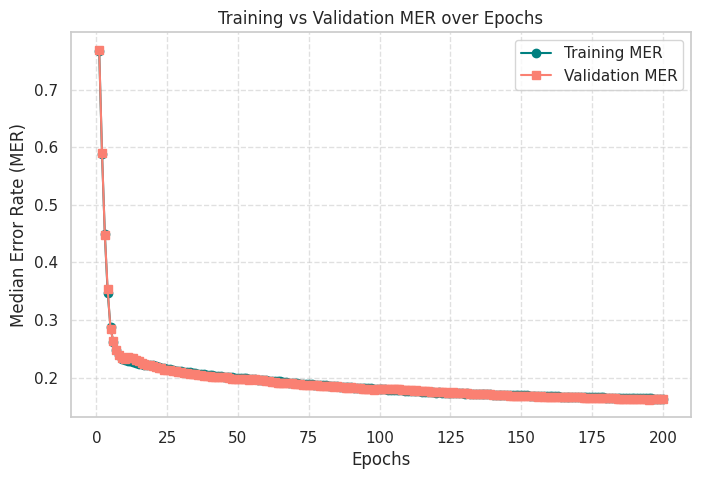

In [ ]:
# Write code to plot the training and vadliation errors (MER) over epochs
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_MERs)+1), train_MERs, label="Training MER", marker='o', color='teal')
plt.plot(range(1, len(valid_MERs)+1), valid_MERs, label="Validation MER", marker='s', color = 'salmon')
plt.xlabel("Epochs")
plt.ylabel("Median Error Rate (MER)")
plt.title("Training vs Validation MER over Epochs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

---
## Build the Multi-layer Perceptron Base Model

In the following, we build a multi-layer perception model with 2 hidden layers of sizes 256 and 128, respectively and ReLu activations.

In [ ]:
# Build a feed-forward network
import torch.nn as nn
model = nn.Sequential(nn.Linear(train_features.shape[1], 256),
                      nn.ReLU(),
                      nn.Linear(256, 128),
                      nn.ReLU(),
                      nn.Linear(128,1))

Let's print out the model achitecture.

In [ ]:
model

Sequential(
  (0): Linear(in_features=105, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=1, bias=True)
)

In [ ]:
# write code to train the MLP network and save training and validation error.

import torch.optim as optim
import torch
import torch.nn as nn # Import nn here as well

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # Define device here

torch.manual_seed(14)
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 150

train_MERs, valid_MERs = [], []
train_losses, valid_losses = [], []

def compute_mer(y_true_scaled, y_pred_scaled):
    eps = 1e-8
    y_true = y_true_scaled.view(-1) * normalization_factor
    y_pred = y_pred_scaled.view(-1) * normalization_factor
    rel = torch.abs(y_pred - y_true) / torch.clamp(y_true, min=eps)
    return torch.median(rel).item()

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    running_train_loss, n_obs = 0.0, 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * features.size(0)
        n_obs += features.size(0)

    epoch_train_loss = running_train_loss / n_obs
    train_losses.append(epoch_train_loss)

    # ---- Validation ----
    model.eval()
    running_valid_loss, n_valid = 0.0, 0
    with torch.no_grad():
        for features, labels in valid_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            running_valid_loss += loss.item() * features.size(0)
            n_valid += features.size(0)

    epoch_valid_loss = running_valid_loss / n_valid
    valid_losses.append(epoch_valid_loss)

    # ---- Compute MER on full sets ----
    with torch.no_grad():
        train_preds = model(train_features.to(device))
        valid_preds = model(valid_features.to(device))
        train_mer = compute_mer(train_labels.to(device), train_preds)
        valid_mer = compute_mer(valid_labels.to(device), valid_preds)
        train_MERs.append(train_mer)
        valid_MERs.append(valid_mer)


    # ---- Logging ----
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_train_loss:.4f}, Valid Loss: {epoch_valid_loss:.4f}, "
              f"Train MER: {train_mer:.4f}, Valid MER: {valid_mer:.4f}")

Epoch [1/150] Train Loss: 9.4223, Valid Loss: 3.1565, Train MER: 0.1730, Valid MER: 0.1713
Epoch [10/150] Train Loss: 1.7428, Valid Loss: 1.9871, Train MER: 0.1041, Valid MER: 0.1139
Epoch [20/150] Train Loss: 1.4799, Valid Loss: 1.9754, Train MER: 0.0991, Valid MER: 0.1073
Epoch [30/150] Train Loss: 1.3003, Valid Loss: 1.8225, Train MER: 0.0954, Valid MER: 0.1060
Epoch [40/150] Train Loss: 1.0973, Valid Loss: 1.8007, Train MER: 0.0827, Valid MER: 0.1004
Epoch [50/150] Train Loss: 0.9955, Valid Loss: 1.8906, Train MER: 0.0807, Valid MER: 0.1047
Epoch [60/150] Train Loss: 0.9536, Valid Loss: 1.9002, Train MER: 0.0775, Valid MER: 0.1025
Epoch [70/150] Train Loss: 0.8260, Valid Loss: 1.8921, Train MER: 0.0771, Valid MER: 0.1041
Epoch [80/150] Train Loss: 0.8051, Valid Loss: 2.0353, Train MER: 0.0772, Valid MER: 0.1045
Epoch [90/150] Train Loss: 0.7352, Valid Loss: 1.9577, Train MER: 0.0764, Valid MER: 0.1083
Epoch [100/150] Train Loss: 0.6605, Valid Loss: 1.9849, Train MER: 0.0620, Valid 

In [ ]:
overall_validation_MER = np.mean(valid_MERs)
print(f"Overall (average) Validation MER across epochs: {overall_validation_MER:.4f}")


Overall (average) Validation MER across epochs: 0.1071


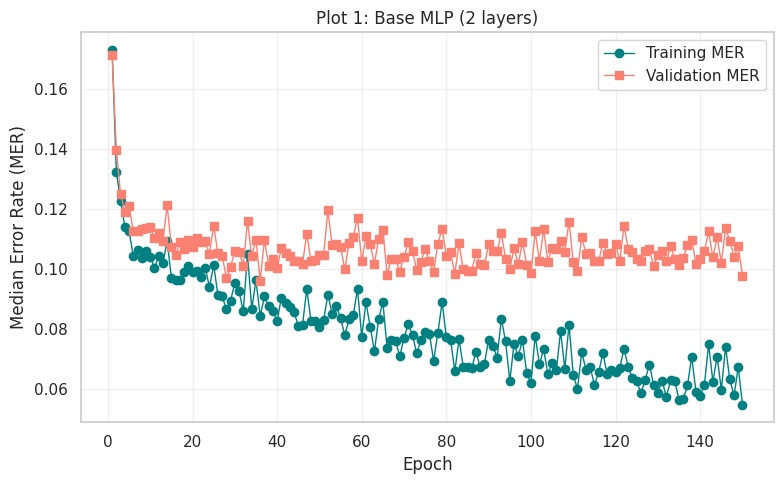

In [ ]:
# Write code to plot the training and validation error (MER) over epochs
import matplotlib.pyplot as plt

epochs = range(1, len(train_MERs) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_MERs, label='Training MER', color='teal', linewidth=1, marker='o' )
plt.plot(epochs, valid_MERs, label='Validation MER', color='salmon', linewidth=1, marker='s')
plt.xlabel('Epoch')
plt.ylabel('Median Error Rate (MER)')
plt.title('Plot 1: Base MLP (2 layers)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Change network architecture


Build MLP with 4 hidden layer of sizes 512, 256, 128, 64, respectively.  

In [ ]:
# building a MLP with 4 hidden layer of sizes 512, 256, 128, 64,
import torch.nn as nn
model = nn.Sequential(
    nn.Linear(train_features.shape[1], 512),  # input -> 512
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)  # final output layer
)



In [ ]:
overall_validation_MER = np.mean(valid_MERs)
print(f"Overall (average) Validation MER across epochs: {overall_validation_MER:.4f}")


Overall (average) Validation MER across epochs: 0.1071


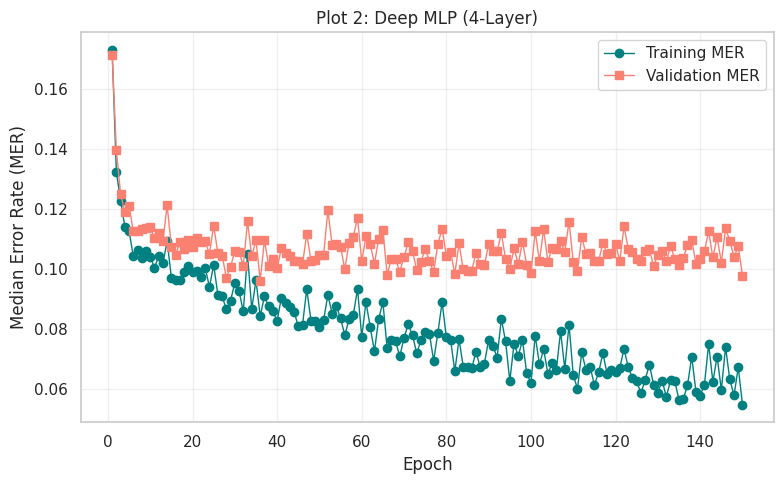

In [ ]:
# plot the training and validation error (MER) over epochs
import matplotlib.pyplot as plt

epochs = range(1, len(train_MERs) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_MERs, label='Training MER', color='teal', linewidth=1, marker='o')
plt.plot(epochs, valid_MERs, label='Validation MER', color='salmon', linewidth=1, marker='s')
plt.xlabel('Epoch')
plt.ylabel('Median Error Rate (MER)')
plt.title('Plot 2: Deep MLP (4-Layer)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Add norm regularization

Use the norm regularization to retrain the above MLP.

Epoch 20/150 | Train MER: 0.0933 | Valid MER: 0.1048
Epoch 40/150 | Train MER: 0.0782 | Valid MER: 0.1019
Epoch 60/150 | Train MER: 0.0632 | Valid MER: 0.0977
Epoch 80/150 | Train MER: 0.0623 | Valid MER: 0.1004
Epoch 100/150 | Train MER: 0.0532 | Valid MER: 0.0977
Epoch 120/150 | Train MER: 0.0642 | Valid MER: 0.1055
Epoch 140/150 | Train MER: 0.0544 | Valid MER: 0.0968


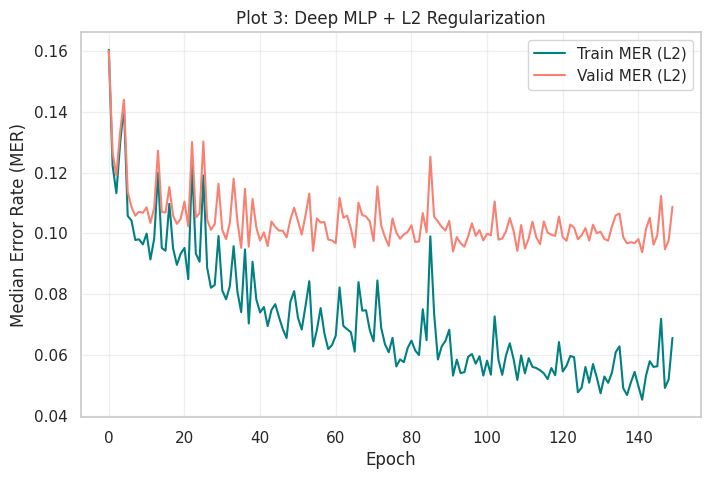

In [ ]:
# plot the training and validation error (MER) over epochs after using norm regularization
# Retrain MLP using L2 norm regularization (weight decay)
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(14)
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # <-- L2 regularization

num_epochs = 150
train_MERs, valid_MERs = [], []

def compute_mer(y_true_scaled, y_pred_scaled):
    eps = 1e-8
    y_true = y_true_scaled.view(-1) * normalization_factor
    y_pred = y_pred_scaled.view(-1) * normalization_factor
    rel = torch.abs(y_pred - y_true) / torch.clamp(y_true, min=eps)
    return torch.median(rel).item()

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    n_obs = 0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * features.size(0)
        n_obs += features.size(0)
    epoch_train_loss = running_train_loss / n_obs

    # Validation
    model.eval()
    with torch.no_grad():
        valid_preds = model(valid_features.to(device))
        train_preds = model(train_features.to(device))
        train_mer = compute_mer(train_labels.to(device), train_preds)
        valid_mer = compute_mer(valid_labels.to(device), valid_preds)
    train_MERs.append(train_mer)
    valid_MERs.append(valid_mer)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Train MER: {train_mer:.4f} | Valid MER: {valid_mer:.4f}")

# Plot MERs after regularization
plt.figure(figsize=(8, 5))
plt.plot(train_MERs, label='Train MER (L2)', color='teal')
plt.plot(valid_MERs, label='Valid MER (L2)', color='salmon')
plt.title('Plot 3: Deep MLP + L2 Regularization')
plt.xlabel('Epoch')
plt.ylabel('Median Error Rate (MER)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
overall_validation_MER = np.mean(valid_MERs)
print(f"Overall (average) Validation MER across epochs: {overall_validation_MER:.4f}")


Overall (average) Validation MER across epochs: 0.1041


---
## Add dropout layer

Add dropout layer to the above MLP.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import os

# define device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# environment variable for deterministic behavior
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'


def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# lists to store losses
train_losses, val_losses = [], []
best_val_loss = float('inf')
best_model_state = None


# test multiple seeds
# for seed in range(0, 1000, 5):  # 200 seeds #too long
# single seed set before
seed = 42
set_seed(seed)

model = nn.Sequential(
    nn.Linear(train_features.shape[1], 512),
    nn.BatchNorm1d(512),  #batchnorm to improve
    nn.LeakyReLU(0.1),
    nn.Dropout(0.2),  #20%
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.LeakyReLU(0.1),
    nn.Dropout(0.2), #20%
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.LeakyReLU(0.1),
    nn.Dropout(0.15), #15%
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.LeakyReLU(0.1),
    nn.Linear(64, 1)
).to(device)

criterion = nn.SmoothL1Loss()
optimizer = optim.AdamW(model.parameters(), lr=0.0007, weight_decay=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)
num_epochs = 250  # Train longer


# training
for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_train_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss_epoch = running_train_loss / len(train_loader)
    train_losses.append(train_loss_epoch) # Append to the list

    # Validation phase
    model.eval()
    running_val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in valid_loader:  # validation dataloader
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item()

    val_loss_epoch = running_val_loss / len(valid_loader)
    val_losses.append(val_loss_epoch) # Append to the list

    scheduler.step(val_loss_epoch)

    # Save best model
    if val_loss_epoch < best_val_loss:
        best_val_loss = val_loss_epoch
        best_model_state = model.state_dict() # Save the state dict
        print(f'✓ Epoch {epoch}: New best! Val Loss: {val_loss_epoch:.4f}')
    else:
        print(f'  Epoch {epoch}: Train Loss: {train_loss_epoch:.4f}, Val Loss: {val_loss_epoch:.4f}')

# load best model
if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"\nLoaded best model with val_loss: {best_val_loss:.4f}")
else:
    print("\nNo best model state saved.")

✓ Epoch 0: New best! Val Loss: 2.6571
✓ Epoch 1: New best! Val Loss: 1.4123
✓ Epoch 2: New best! Val Loss: 0.6559
✓ Epoch 3: New best! Val Loss: 0.5400
✓ Epoch 4: New best! Val Loss: 0.4786
✓ Epoch 5: New best! Val Loss: 0.4680
  Epoch 6: Train Loss: 0.4992, Val Loss: 0.4842
  Epoch 7: Train Loss: 0.4959, Val Loss: 0.4950
  Epoch 8: Train Loss: 0.4893, Val Loss: 0.4923
✓ Epoch 9: New best! Val Loss: 0.4643
✓ Epoch 10: New best! Val Loss: 0.4608
✓ Epoch 11: New best! Val Loss: 0.4602
  Epoch 12: Train Loss: 0.4528, Val Loss: 0.5238
✓ Epoch 13: New best! Val Loss: 0.4405
  Epoch 14: Train Loss: 0.4456, Val Loss: 0.4454
  Epoch 15: Train Loss: 0.4389, Val Loss: 0.4590
  Epoch 16: Train Loss: 0.4472, Val Loss: 0.4520
✓ Epoch 17: New best! Val Loss: 0.4222
  Epoch 18: Train Loss: 0.4261, Val Loss: 0.4568
  Epoch 19: Train Loss: 0.4231, Val Loss: 0.4332
  Epoch 20: Train Loss: 0.4194, Val Loss: 0.4309
  Epoch 21: Train Loss: 0.4184, Val Loss: 0.4576
  Epoch 22: Train Loss: 0.4266, Val Loss: 

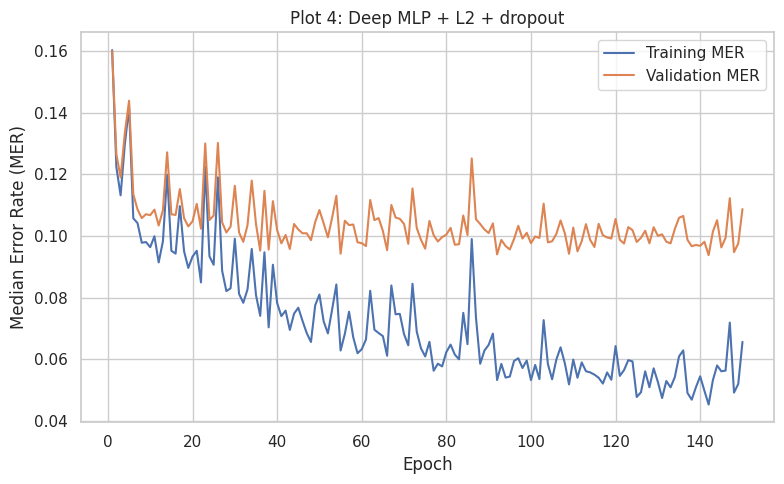

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_MERs)+1), train_MERs, label='Training MER')
plt.plot(range(1, len(valid_MERs)+1), valid_MERs, label='Validation MER')
plt.title('Plot 4: Deep MLP + L2 + dropout')
plt.xlabel('Epoch'); plt.ylabel('Median Error Rate (MER)')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    valid_preds = model(valid_features.to(device))

# Define the compute_mer function
def compute_mer(y_true_scaled, y_pred_scaled):
    eps = 1e-8
    y_true = y_true_scaled.view(-1) * normalization_factor
    y_pred = y_pred_scaled.view(-1) * normalization_factor
    rel = torch.abs(y_pred - y_true) / torch.clamp(y_true, min=eps)
    return torch.median(rel).item()

final_valid_mer = compute_mer(valid_labels.to(device), valid_preds)
print(f"Final Validation MER: {final_valid_mer:.4f}")

Final Validation MER: 0.0813


## Some other model variations


In [ ]:
# plot the training and validation error (MER) over epochs after using norm regularization
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(train_features.shape[1], 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)


import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)
model = model.to(device)
criterion = nn.SmoothL1Loss()
optimizer = optim.AdamW(model.parameters(), lr=0.0007, weight_decay=0.0001)  # keep L2 norm regularization

num_epochs = 150
train_MERs, valid_MERs = [], []

def compute_mer(y_true_scaled, y_pred_scaled):
    eps = 1e-8
    y_true = y_true_scaled.view(-1) * normalization_factor
    y_pred = y_pred_scaled.view(-1) * normalization_factor
    rel = torch.abs(y_pred - y_true) / torch.clamp(y_true, min=eps)
    return torch.median(rel).item()

for epoch in range(num_epochs):
    model.train()
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_preds = model(train_features.to(device))
        valid_preds = model(valid_features.to(device))
        train_mer = compute_mer(train_labels.to(device), train_preds)
        valid_mer = compute_mer(valid_labels.to(device), valid_preds)

    train_MERs.append(train_mer)
    valid_MERs.append(valid_mer)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Train MER: {train_mer:.4f} | Valid MER: {valid_mer:.4f}")

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(train_MERs, label='Train MER (Dropout + L2)', color='royalblue')
plt.plot(valid_MERs, label='Valid MER (Dropout + L2)', color='tomato')
plt.title('Training vs Validation MER (Dropout + L2 Regularization)')
plt.xlabel('Epoch')
plt.ylabel('Median Error Rate (MER)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

KeyboardInterrupt: 

---
## Save Model


In [ ]:

model = nn.Sequential(
    nn.Linear(train_features.shape[1], 512),
    nn.BatchNorm1d(512),
    nn.LeakyReLU(0.1),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.LeakyReLU(0.1),
    nn.Dropout(0.2),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.LeakyReLU(0.1),
    nn.Dropout(0.15),
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.LeakyReLU(0.1),
    nn.Linear(64, 1)
).to(device)

# Now load the best weights
model.load_state_dict(best_model_state)
model.eval()

# Make predictions on test set
with torch.no_grad():
    test_features_gpu = test_features.to(device)
    test_predictions = model(test_features_gpu).cpu().numpy()

# Save everything in checkpoint.pth
torch.save({
    # Model weights
    'model_state_dict': best_model_state,

    # Model architecture info
    'architecture': {
        'input_size': train_features.shape[1],
        'hidden_layers': [512, 256, 128, 64],
        'output_size': 1,
        'use_batchnorm': True,
        'activation': 'LeakyReLU',
        'dropout_rates': [0.2, 0.2, 0.15]
    },

    # Training configuration
    'hyperparameters': {
        'learning_rate': 0.0007,
        'weight_decay': 0.0001,
        'dropout': [0.2, 0.2, 0.15],
        'batch_size': 128,
        'num_epochs': 250,
        'optimizer': 'AdamW',
        'criterion': 'SmoothL1Loss',
        'scheduler': 'ReduceLROnPlateau',
        'seed': 42
    },

    # Performance metrics
    'best_val_loss': best_val_loss,
    'train_losses': train_losses,
    'val_losses': val_losses,

    # Predictions
    'test_predictions': test_predictions,

}, 'checkpoint.pth')

print("✓ Checkpoint saved successfully to 'checkpoint.pth'")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Test predictions shape: {test_predictions.shape}")

# Download the file
from google.colab import files
files.download('checkpoint.pth')
print("✓ Checkpoint downloaded!")

✓ Checkpoint saved successfully to 'checkpoint.pth'
Best validation loss: 0.392489
Test predictions shape: (4964, 1)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Checkpoint downloaded!


---
## Inference on test data



In [ ]:
# submission - multiply normalization factor again
model.eval()
preds = []

with torch.no_grad():
    for b in test_loader:
        x = b[0] if isinstance(b, (list, tuple)) else b
        preds.append(model(x.to(device)).squeeze(-1).cpu().numpy())

preds = (np.concatenate(preds).ravel()) * 100000
pd.DataFrame({"ID": test_ID, "SALE_PRICE": preds}).to_csv("submission.csv", index=False)
display(pd.read_csv("submission.csv").head())

,ID,SALE_PRICE
0,144650,530543.25
1,495961,477794.47
2,582423,460654.34
3,966643,260655.55
4,795229,545702.90


---
## Evaluate the profit of iBuyer business model



In [ ]:
##  Load your best model from your saved checkpoint.pth file.

import torch
import torch.nn as nn

# Load the checkpoint
checkpoint = torch.load('checkpoint.pth', weights_only=False)


arch = checkpoint['architecture']
model = nn.Sequential(
    nn.Linear(arch['input_size'], 512),
    nn.BatchNorm1d(512),
    nn.LeakyReLU(0.1),
    nn.Dropout(arch['dropout_rates'][0]),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.LeakyReLU(0.1),
    nn.Dropout(arch['dropout_rates'][1]),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.LeakyReLU(0.1),
    nn.Dropout(arch['dropout_rates'][2]),
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.LeakyReLU(0.1),
    nn.Linear(64, arch['output_size'])
)


# load the trained weights
model.load_state_dict(checkpoint['model_state_dict'])

# move to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

model.eval()

# predicted prices on valid
with torch.no_grad():
    valid_predicted_scaled = model(valid_features.to(device))

# unscale predictions
valid_predicted_prices = valid_predicted_scaled.cpu().numpy().flatten() * normalization_factor
valid_actual_prices = valid_labels.cpu().numpy().flatten() * normalization_factor

valid_predicted_prices

array([591434.1 , 643432.56, 305808.88, ..., 628547.1 , 495273.34,
       268461.7 ], dtype=float32)

Compute the signed error rates (without taking the absolute value sign), that is

$$
\text{Signed Error Rate} = \frac{\text{Predicted Price}-\text{Actual Price}}{\text{Actual Price}}
$$


### Analysis and visualization of valid errors



**Question 1**: what is the bias of the prediction errors? Include the histogram of prediction errors and the bias in your report.

In [ ]:
# Compute signed error rates
prediction_errors = (valid_predicted_prices - valid_actual_prices) / valid_actual_prices

prediction_errors

array([ 0.0434231 ,  0.09056366,  0.19925049, ..., -0.00230615,
       -0.16480044, -0.04428022], dtype=float32)

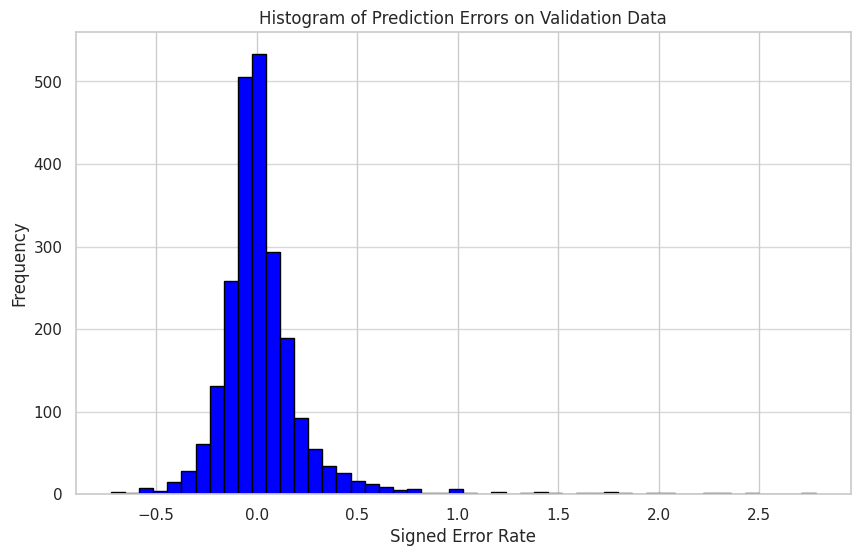

Bias of prediction errors: 0.0301


In [ ]:
#histogram of prediction errors.
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.hist(prediction_errors, bins=50, color='blue', edgecolor='black')
plt.title('Histogram of Prediction Errors on Validation Data')
plt.xlabel('Signed Error Rate')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Question 1: what is the bias of the prediction errors?
bias = np.mean(prediction_errors)
print(f"Bias of prediction errors: {bias:.4f}")

### Profit Analysis

In the following profit analysis, we assume the iBuyer will make an offer to every property in the valid data based on their predicted price $PP$. We assume the iBuyer decides the offer price $OP$ according to
$$
OP = \frac{PP}{1+\alpha},
$$
where $\alpha$ is the (targted) profit margin of the iBuyer.
Here we assume the profit margin has already taken into consideration the commission fee charged by the iBuyer
and various costs associated such as transaction cost, administration cost, and holding cost. Note that the commission fee charged by Zillow is often around $7.5\%$ and Zillow may charge additional repair costs after home inspection. Thus we take $\alpha=12\%$ in this case study.

We further assume that the iBuyer can resell the property at the same
price as the broker in the future once the property is bought. In other words, the resell price is equal to the sale price in the valid data. This assumption may not be exactly true in practice and the iBuyer may sell the house at either a higher or lower price depending on the market trend. But our conclusion will not change too much.

Based on the above two assumptions, we can now determine the percentage profit
for a property bought by the iBuyer as
$$
\frac{SP- OP}{OP}.
$$
We use the percentage profit instead of the absolute profit because the iBuyer cannot hope to purchase all houses in the market. Therefore, the percentage profit is a better measure of the profitability of the iBuyer business model.
 The aim of the iBuyer in this simplified setting is to purchase properties for less money than they are sold for, to generate a profit.

In [ ]:
profit_margin = 0.12

**Question 2**: Consider the hypothetical scenario where the offers are all accepted regardless of their values,
what is the average percentage profit? Do you see a big difference compared to the profit margin $\alpha$? Include your answers in the report.

In [ ]:
import numpy as np

alpha = 0.12  # target profit margin (12%)

# rename for clarity
SP = valid_actual_prices          # sale price in valid data
PP = valid_predicted_prices       # model-predicted resale price

# Offer if we target margin alpha
OP = PP / (1 + alpha)

# Percentage profit if EVERY offer is accepted
pct_profit_all = (SP - OP) / OP           # = SP/OP - 1 = (1+alpha)*SP/PP - 1
avg_pct_profit_all = float(np.mean(pct_profit_all))

print(f"Mean % profit if all offers are accepted: {avg_pct_profit_all:.4f}")
print(f"Difference vs target α={alpha:.2f}: {avg_pct_profit_all - alpha:.4f} (percentage points)")


Mean % profit if all offers are accepted: 0.1358
Difference vs target α=0.12: 0.0158 (percentage points)


**Offer Acceptance Rule**


However, not every offer will be accepted by the home owner. Given an offer price, whether the homeowner accepts it
depends on the homeowner's perceived valuation. For the current dataset, we lack enough data to determine the homeowner's perceived valuation of the property. However, the actual sale price in the valid data serves as a reasonable proxy of the homeowner's perceived valuation. Therefore, we assume that the home owner will accept the offer, if
$$
OP> (1-\beta) SP,
$$
where $\beta$ is a discounting factor. Here the discounting factor captures the commission fee charged
by the conventional realtors which is around 6%, as well as the convenience factor that models
how much the homeowner values the quick transaction services of the iBuyer over the conventional
relator. We assume $\beta = 10\%$ in this case.

**Question 3**: Based on the sale price in the valid data and the acceptance rule, what is the mean percentage profit among all accepted offers? Do you see a big difference compared to the targeted profit margin $\alpha$?  Include your answers in your report.  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Params
alpha = 0.12  # target profit margin
beta  = 0.10  # discounting factor

# Aliases
SP = valid_actual_prices        # actual sale prices (validation)
PP = valid_predicted_prices     # predicted resale prices (validation)

# Offer price per rule: OP = PP / (1 + alpha)
OP = PP / (1 + alpha)

# Acceptance rule: OP > (1 - beta) * SP
accepted_mask = OP > (1 - beta) * SP

# --- What the question asks: mean % profit among ACCEPTED offers ---
# Profit% = (SP - OP) / OP
accepted_profit_pct = (SP[accepted_mask] - OP[accepted_mask]) / OP[accepted_mask]
mean_accepted_profit = float(np.mean(accepted_profit_pct))

print(f"Acceptance rate: {accepted_mask.mean():.2%}")
print(f"Mean % profit among accepted offers: {mean_accepted_profit:.4f}")
print(f"Difference vs target α={alpha:.2f}: {mean_accepted_profit - alpha:.4f} (percentage points)")



Acceptance rate: 44.63%
Mean % profit among accepted offers: -0.0262
Difference vs target α=0.12: -0.1462 (percentage points)


Let's plot the histogram of the prediction errors for those properties whose home owners accepted the offer.

**Question 4**: What is the bias of the prediction errors when restricting to those properties whose owners accepted the offer? Based on the histogram and bias, can you explain your answers to Question 3?

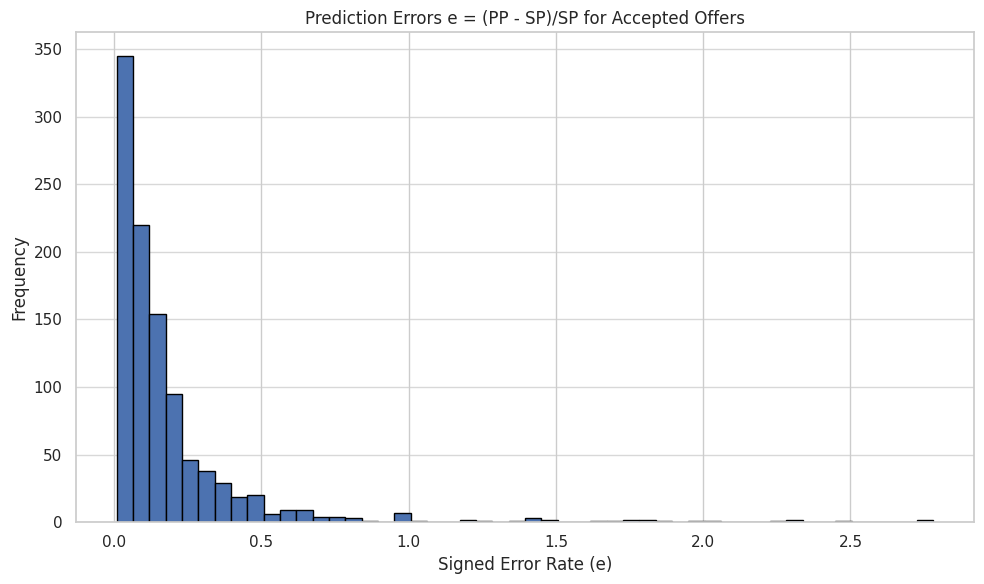

In [ ]:
accepted_prediction_errors = prediction_errors[accepted_mask]
plt.figure(figsize=(10,6))
plt.hist(accepted_prediction_errors, bins=50, edgecolor='black')
plt.title('Prediction Errors e = (PP - SP)/SP for Accepted Offers')
plt.xlabel('Signed Error Rate (e)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [ ]:
# Question 4: What is the bias of the prediction errors when restricting to those properties whose owners accepted the offer?
bias_accepted = np.mean(accepted_prediction_errors)
print(f"Bias of prediction errors for accepted offers: {bias_accepted:.4f}")

Bias of prediction errors for accepted offers: 0.1912
